# DALL-E Mini Image Generator
### Generate Square (1:1) Digital Art from a Text Prompt using DALL-E Mini

---

**References:**
- [DALL-E Mini Image Generator – Google Colab](https://colab.research.google.com/github/robgon-art/e-dall-e/blob/main/DALL_E_Mini_Image_Generator.ipynb)
- [kuprel/min-dalle – GitHub](https://github.com/kuprel/min-dalle)

---

**What this notebook does:**
1. 📦 Installs all required libraries
2. 🤖 Loads the DALL-E Mini model (via `min-dalle`)
3. ✏️ Sets your text prompt & generation parameters
4. 🖼️ Generates square (1:1) images from the prompt, displays and saves results

> ⚠️ **Important:** Make sure to enable **GPU** runtime.  
> Go to `Runtime → Change runtime type → Hardware accelerator → T4 GPU`


## Section 1: Verify GPU

In [1]:
!nvidia-smi -L

GPU 0: Tesla T4 (UUID: GPU-1b51aa67-9aa2-3375-79b9-71188022851d)



## Section 2: Install Dependencies

In [2]:
print("Installing dependencies...")

# DALL-E Mini (PyTorch-based lightweight version)
!pip install -q min-dalle

# PyTorch ecosystem
!pip install -q torch torchvision

# CLIP
!pip install -q ftfy regex tqdm
!pip install -q git+https://github.com/openai/CLIP.git

# Visualization
!pip install -q Pillow matplotlib

print("\n All packages installed successfully!")


Installing dependencies...
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done

 All packages installed successfully!


## 🤖 Section 3: Load DALL-E Mini Model

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")

PyTorch version : 2.11.0+cu128
CUDA available  : True
GPU             : Tesla T4


In [4]:
from min_dalle import MinDalle

device_str = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device_str}")

model = MinDalle(
    models_root='./pretrained',
    dtype=torch.float16,   # ← was jnp.float16 (wrong library)
    device=device_str,     # ← was hardcoded 'cuda' (crashes on CPU)
    is_mega=False,         # Set True for better quality (needs more VRAM)
    is_reusable=True
)

print("DALL-E Mini model loaded successfully!")

Using device: cuda
using device cuda
downloading tokenizer params
intializing TextTokenizer
downloading encoder params
initializing DalleBartEncoder
downloading decoder params
initializing DalleBartDecoder
downloading detokenizer params
initializing VQGanDetokenizer
DALL-E Mini model loaded successfully!



## Section 4: Set Your Text Prompt & Parameters

In [5]:
TEXT_PROMPT           = "a place wih beautiful scenery, digital art"
NUM_IMAGES            = 9       # Total images in grid
GRID_SIZE             = 3       # 3×3 grid (must satisfy GRID_SIZE² == NUM_IMAGES)
SEED                  = 42      # Change for different results
SUPERCONDITION_FACTOR = 16      # Higher = more prompt-faithful
TOP_K                 = 256

print(f" Prompt         : {TEXT_PROMPT}")
print(f" Images to gen : {NUM_IMAGES}")
print(f" Seed           : {SEED}")
print(f" Supercondition : {SUPERCONDITION_FACTOR}")

 Prompt         : a place wih beautiful scenery, digital art
 Images to gen : 9
 Seed           : 42
 Supercondition : 16


## 🖼️ Section 4(Part 2): Generate Square Images (1:1)

 Generating 9 images for: 'a place wih beautiful scenery, digital art'

tokenizing text
['Ġa']
['Ġplace']
['Ġw', 'ih']
['Ġbeautiful']
['Ġscenery', ',']
['Ġdigital']
['Ġart']
11 text tokens [0, 58, 2403, 75, 2025, 1687, 12067, 11, 1189, 241, 2]
encoding text tokens


/usr/local/lib/python3.12/dist-packages/min_dalle/min_dalle.py:201: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=self.dtype):
/usr/local/lib/python3.12/dist-packages/min_dalle/min_dalle.py:208: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=self.dtype):
/usr/local/lib/python3.12/dist-packages/min_dalle/min_dalle.py:239: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=self.dtype):
/usr/local/lib/python3.12/dist-packages/min_dalle/min_dalle.py:251: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=torch.float32):


detokenizing image

 Images generated!


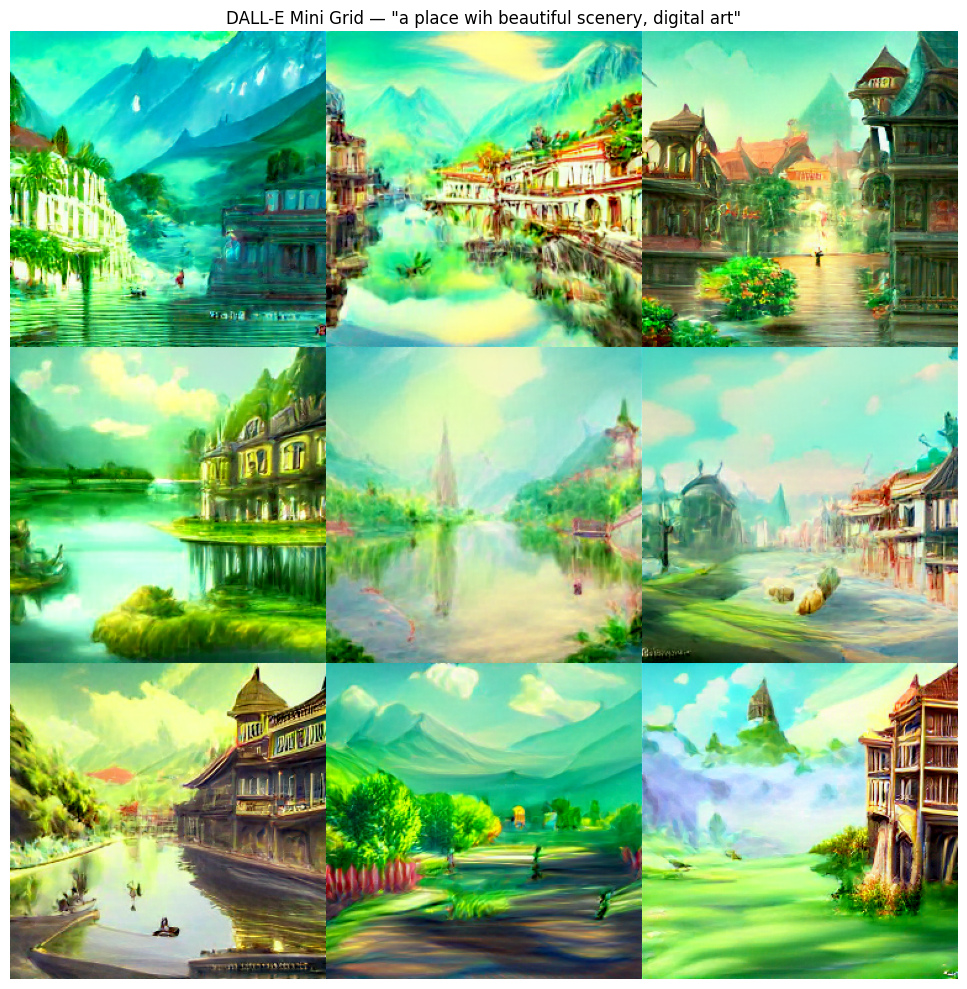

 Grid saved as 'dalle_mini_grid.png'


In [6]:
print(f" Generating {NUM_IMAGES} images for: '{TEXT_PROMPT}'\n")

image = model.generate_image(
    text=TEXT_PROMPT,
    seed=SEED,
    grid_size=GRID_SIZE,
    is_seamless=False,
    temperature=1,
    top_k=TOP_K,
    supercondition_factor=SUPERCONDITION_FACTOR,
    is_verbose=True
)

print("\n Images generated!")

plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis('off')
plt.title(f'DALL-E Mini Grid — "{TEXT_PROMPT}"', fontsize=12)
plt.tight_layout()
plt.savefig('dalle_mini_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Grid saved as 'dalle_mini_grid.png'")

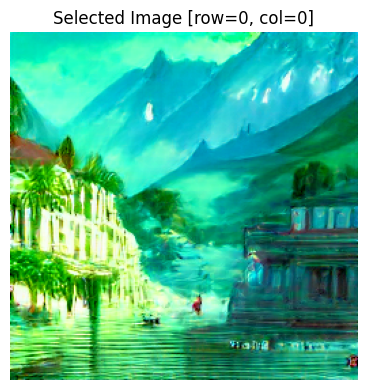

Selected image saved as 'selected_image.png'


In [8]:
BEST_ROW  = 0
BEST_COL  = 0
tile_size = 256

img_array     = np.array(image)
r0            = BEST_ROW * tile_size
c0            = BEST_COL * tile_size
selected      = img_array[r0:r0+tile_size, c0:c0+tile_size]
selected_image = Image.fromarray(selected)

plt.figure(figsize=(4, 4))
plt.imshow(selected_image)
plt.axis('off')
plt.title(f'Selected Image [row={BEST_ROW}, col={BEST_COL}]')
plt.tight_layout()
plt.show()

selected_image.save('selected_image.png')
print("Selected image saved as 'selected_image.png'")

---
## 📝 Summary

| Step | What happened |
|------|---------------|
| 1    | Installed `min-dalle`, CLIP, and helper libs |
| 2    | Loaded **DALL-E Mini** (MinDalle) with safe device + correct dtype |
| 3    | Configured text prompt and generation parameters |
| 4    | Generated a 3×3 grid of square images and selected the best one |

### Files saved
- `dalle_mini_grid.png` — Full generation grid
- `selected_image.png` — Chosen square image

### References
- Brett Kuprel, *min-dalle* — [GitHub](https://github.com/kuprel/min-dalle)
